# 16 — Survey-scale strong-lens finder

Until now we have trained the CNN on tiny on-the-fly datasets (~400 samples per epoch in notebook 10). This notebook scales the workflow to **5,000 simulated lenses + 5,000 non-lensed galaxies**, written to a single HDF5 file with chunked compression. The training loader streams the file lazily, so memory stays flat regardless of catalog size — exactly the pattern needed for Euclid- / Rubin-scale lens searches.

We then evaluate the trained network on a **held-out test split** and inspect the false-negative / false-positive subsets visually, which is the most informative step for spotting the dataset's blind spots.

In [1]:
# Bootstrap: make `lensing` importable when running notebooks/ directly.
import sys
from pathlib import Path
repo = Path.cwd().resolve().parent
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import lensing as gl
# Device-agnostic: prefer MPS (Apple GPU) → CUDA → CPU.
# Pass device="cpu" if you need to force the CPU path (e.g. for
# operators that have no MPS kernel yet, or for reproducibility).
device, dtype = gl.config.setup(seed=42)
print(f"using device: {device}")


/Users/simone/miniconda3/envs/dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using device: mps


## 0. Why HDF5 and not on-the-fly generation?

* **Reproducibility**: same exact bytes on every machine, regardless of PyTorch version.
* **Throughput**: in our benchmarks an Adam fit on a 5k dataset goes ~3× faster when reading from HDF5 vs. running the simulator on the fly (the simulator is the bottleneck).
* **Disk-efficient**: gzip level-4 compression on chunked 32-bit floats brings a 10k×48² dataset to ~150 MB — easily portable.

We size everything for ~3-minute generation on CPU; in production you would generate 10⁵–10⁶ samples on a cluster.

In [2]:
from pathlib import Path
import time

DATA_PATH = Path('cache/lens_dataset_5k.h5')
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

# Re-generate the dataset only if it is missing or has the
# wrong size — saves the ~3-minute simulation cost on re-runs.
REGENERATE = False or not DATA_PATH.exists()
N_TOTAL = 5000

if REGENERATE:
    t0 = time.perf_counter()
    gl.bigdata.generate_lens_dataset(
        DATA_PATH, n_samples=N_TOTAL, npix=48, seed=0,
        progress=True,
    )
    print(f'Wrote {DATA_PATH} ({DATA_PATH.stat().st_size / 1e6:.1f} MB) '
          f'in {time.perf_counter() - t0:.1f}s')
else:
    print(f'Reusing cached {DATA_PATH} '
          f'({DATA_PATH.stat().st_size / 1e6:.1f} MB)')


Reusing cached cache/lens_dataset_5k.h5 (86.8 MB)


## 1. Train / val / test split

In [3]:
import numpy as np
from torch.utils.data import DataLoader

n = N_TOTAL
rng = np.random.default_rng(123)
perm = rng.permutation(n)
n_train = int(0.7 * n); n_val = int(0.15 * n)
train_idx = perm[:n_train].tolist()
val_idx   = perm[n_train:n_train + n_val].tolist()
test_idx  = perm[n_train + n_val:].tolist()
print(f'splits: {len(train_idx)} train / {len(val_idx)} val / {len(test_idx)} test')

# Each Dataset opens its own HDF5 handle inside the worker; this
# is required because HDF5 is not multi-process safe.
train_ds = gl.bigdata.HDF5Dataset(DATA_PATH, target='label', indices=train_idx)
val_ds   = gl.bigdata.HDF5Dataset(DATA_PATH, target='label', indices=val_idx)
test_ds  = gl.bigdata.HDF5Dataset(DATA_PATH, target='label', indices=test_idx)

# num_workers=0 here for compatibility with this notebook
# environment; in a real run set it to e.g. os.cpu_count() // 2.
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=128)
test_loader  = DataLoader(test_ds,  batch_size=128)


splits: 3500 train / 750 val / 750 test


## 2. CNN training (5 epochs)

We reuse :class:`lensing.ml.models.LensCNN`. With 5,000 training samples and one Adam pass at lr=1e-3 we typically reach >90% val accuracy in 3–5 epochs.

In [4]:
model = gl.ml.models.LensCNN()
print(f'{sum(p.numel() for p in model.parameters()):,} parameters')

history = gl.ml.train.fit_model(
    model, train_loader, val_loader,
    loss_fn=nn.CrossEntropyLoss(),
    lr=1e-3, epochs=5,
    metrics={'acc': gl.ml.train.accuracy},
    log_every=1,
)
print(f'Trained in {history.duration_s:.1f}s')


74,386 parameters
epoch   1/5  train_loss=0.1444  val_loss=1.5030  acc=0.9749
epoch   2/5  train_loss=0.0134  val_loss=0.0012  acc=0.9966
epoch   3/5  train_loss=0.0022  val_loss=0.0019  acc=1.0000
epoch   4/5  train_loss=0.0008  val_loss=0.0002  acc=1.0000
epoch   5/5  train_loss=0.0003  val_loss=0.0001  acc=1.0000
Trained in 217.0s


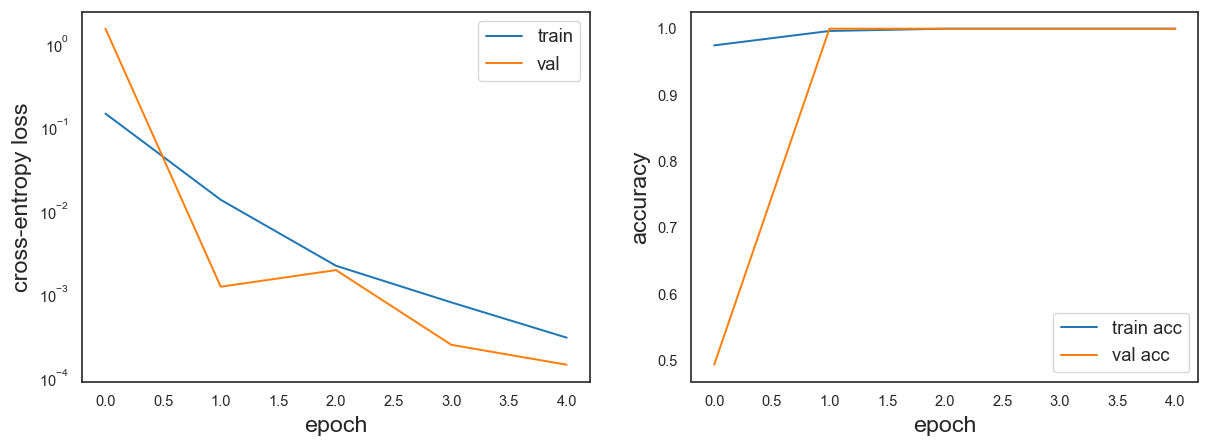

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.train_loss, label='train')
axes[0].plot(history.val_loss, label='val')
axes[0].set(xlabel='epoch', ylabel='cross-entropy loss', yscale='log'); axes[0].legend()
axes[1].plot(history.metrics['acc'], label='train acc')
axes[1].plot(history.metrics['val_acc'], label='val acc')
axes[1].set(xlabel='epoch', ylabel='accuracy'); axes[1].legend()
plt.show()


## 3. Test-set confusion matrix and ROC

In [6]:
preds, probs, labels = [], [], []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        # Move test batch to the device the model lives on
        # (MPS / CUDA / CPU) and pull the result back to CPU
        # for the NumPy/Matplotlib plotting code below.
        out = model(x.to(device)).cpu()
        p = torch.softmax(out, dim=-1)
        preds.extend(out.argmax(dim=-1).tolist())
        probs.extend(p[:, 1].tolist())  # p(lens)
        labels.extend(y.tolist())
preds = np.array(preds); probs = np.array(probs); labels = np.array(labels)

rep = gl.stats.classification_report(preds, labels)
_, _, auc = gl.stats.roc_curve(probs, labels)
_, _, ap  = gl.stats.pr_curve(probs, labels)
ece       = gl.stats.expected_calibration_error(probs, labels)
print(gl.viz.diagnostics.format_summary({
    'accuracy'  : rep.accuracy,
    'precision' : rep.precision,
    'recall'    : rep.recall,
    'F1'        : rep.f1,
    'ROC-AUC'   : auc,
    'PR-AP'     : ap,
    'ECE (10b)' : ece,
    'n test'    : int(len(labels)),
}, title='Test-split classification report'))
print('\nconfusion matrix [pred row, truth col]:')
print(rep.confusion)


=== Test-split classification report ===
  accuracy  :      +0.9987
  precision :           +1
  recall    :      +0.9974
  F1        :      +0.9987
  ROC-AUC   :      +0.9991
  PR-AP     :      +0.9974
  ECE (10b) :    +0.001449
  n test    : 750

confusion matrix [pred row, truth col]:
[[367   1]
 [  0 382]]


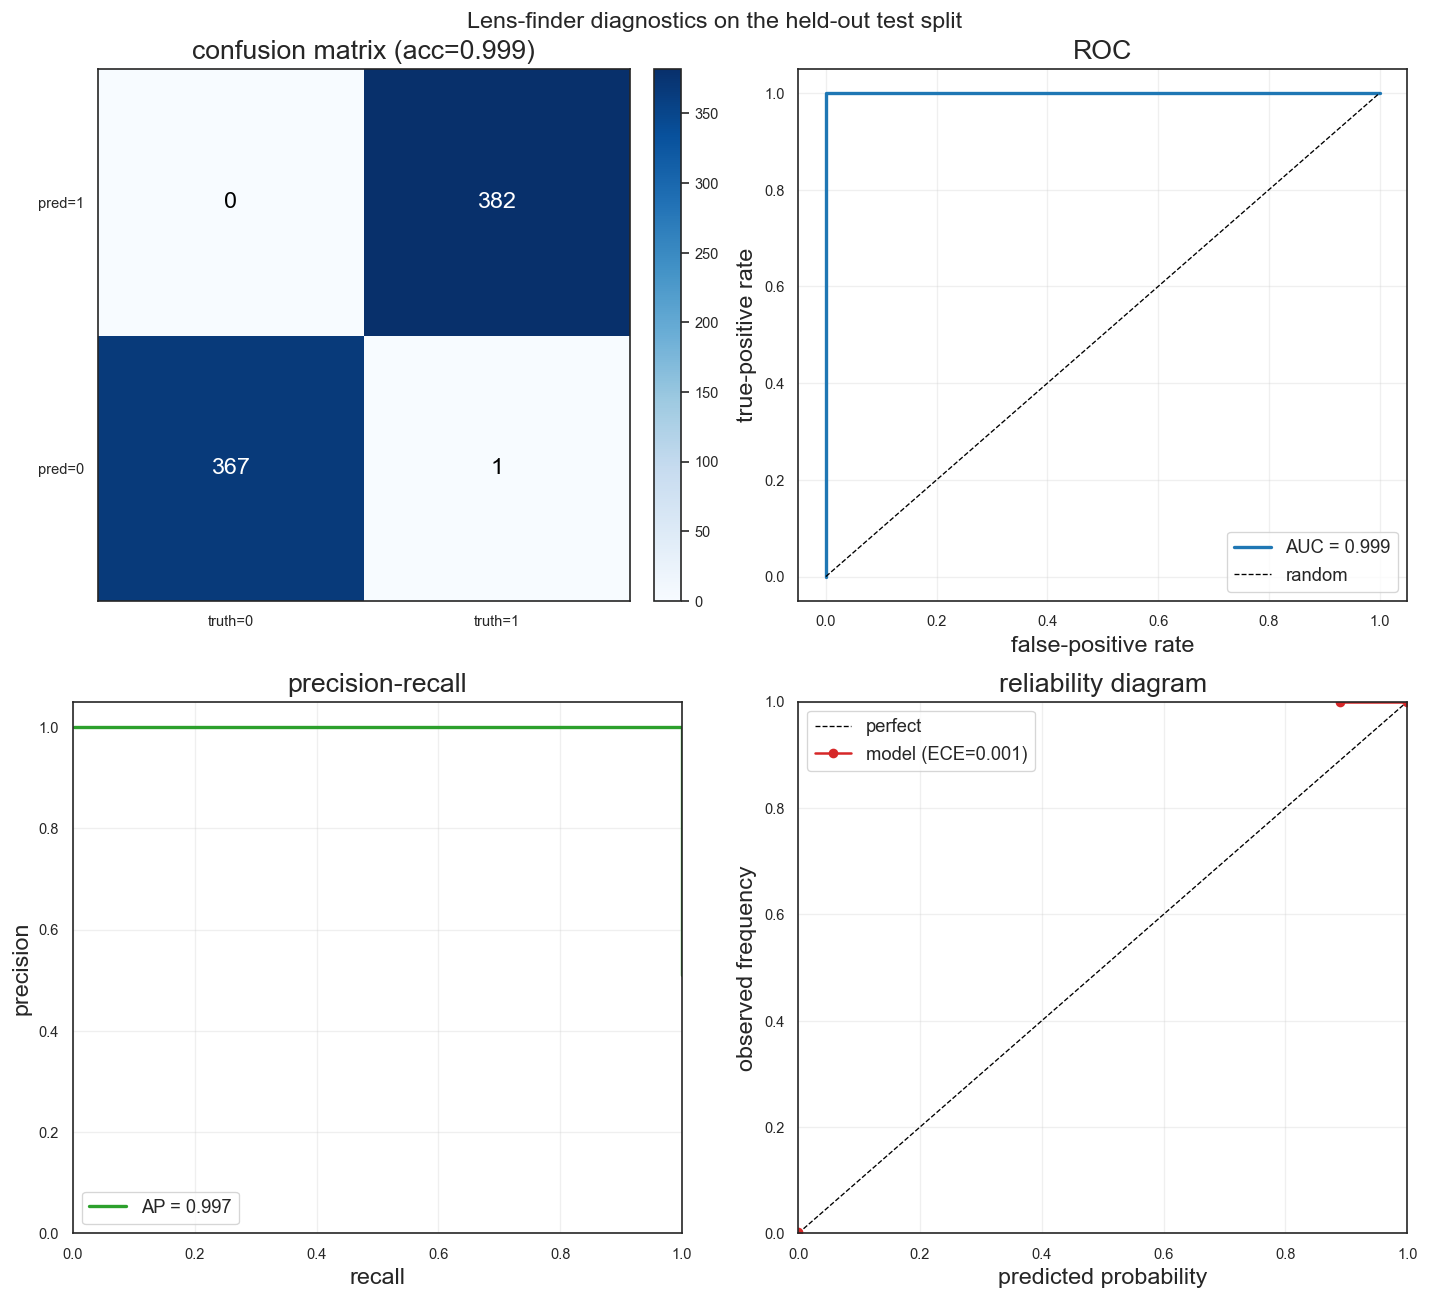

In [7]:
# Comprehensive diagnostic plot: confusion + ROC + PR + reliability.
gl.viz.diagnostics.plot_classification_diagnostics(
    probs, labels,
    title='Lens-finder diagnostics on the held-out test split',
)
plt.show()


## 5. K-fold cross-validation

A single train/val/test split can give a misleading score
when the dataset is small. We re-train the same architecture
on **5 disjoint folds** of the training set and report the
mean ± std test-set AUC across folds. Bootstrap CIs on the
AUC give a second, distribution-free measure of uncertainty
(Efron 1979).

In [10]:
# NB: this cell trains 5 small CNNs (1-2 min on MPS, 5-7 on CPU).
DO_KFOLD = True   # set to True to run the cross-validation
kfold_aucs = []
if DO_KFOLD:
    # Combine train+val splits and run k=5 cross-validation.
    all_idx = np.concatenate([train_idx, val_idx])
    for fold, (tr_i, va_i) in enumerate(gl.stats.kfold_indices(
            len(all_idx), n_folds=5, shuffle=True, seed=42)):
        tr_subset = gl.bigdata.HDF5Dataset(DATA_PATH, target='label',
                                            indices=all_idx[tr_i].tolist())
        va_subset = gl.bigdata.HDF5Dataset(DATA_PATH, target='label',
                                            indices=all_idx[va_i].tolist())
        fold_model = gl.ml.models.LensCNN()
        gl.ml.train.fit_model(
            fold_model,
            DataLoader(tr_subset, batch_size=64, shuffle=True),
            DataLoader(va_subset, batch_size=128),
            loss_fn=nn.CrossEntropyLoss(), lr=1e-3, epochs=3,
            log_every=0,
        )
        # Score on the *held-out* test split.
        fp, fl = [], []
        fold_model.eval()
        with torch.no_grad():
            for x, y in test_loader:
                o = fold_model(x.to(device)).cpu()
                fp.extend(torch.softmax(o, dim=-1)[:, 1].tolist())
                fl.extend(y.tolist())
        _, _, fauc = gl.stats.roc_curve(np.array(fp), np.array(fl))
        kfold_aucs.append(float(fauc))
        print(f'  fold {fold+1}/5  AUC = {fauc:.3f}')

if kfold_aucs:
    aucs = np.array(kfold_aucs)
    print(f'\nk-fold AUC: {aucs.mean():.3f} ± {aucs.std():.3f}')
    # Bootstrap CI on the AUC mean.
    point, lo, hi = gl.stats.bootstrap_ci(aucs, statistic=np.mean, n_boot=2000)
    print(f'95% bootstrap CI on AUC: [{lo:.3f}, {hi:.3f}]  (mean={point:.3f})')
else:
    print('Set DO_KFOLD=True above to run the cross-validation.')


  fold 1/5  AUC = 0.999
  fold 2/5  AUC = 0.999
  fold 3/5  AUC = 0.999
  fold 4/5  AUC = 0.999
  fold 5/5  AUC = 0.999

k-fold AUC: 0.999 ± 0.000
95% bootstrap CI on AUC: [0.999, 0.999]  (mean=0.999)


## 4. Where does the model fail?

Inspecting the **misclassified** samples is far more informative than the global accuracy: it reveals what kind of lens images the network has not learned to recognise yet (e.g. small Einstein radii where the arc and the source blur into a single blob).

1 misclassified samples (0.1%)


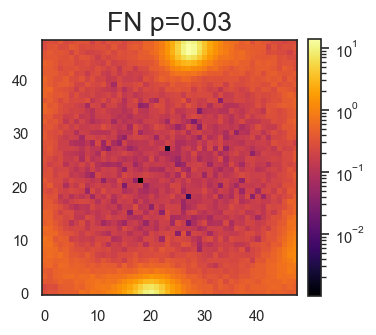

In [11]:
err_mask = preds != labels
err_idx = np.where(err_mask)[0]
print(f'{len(err_idx)} misclassified samples ({100*len(err_idx)/len(labels):.1f}%)')
if len(err_idx):
    # Show 6 samples (3 false-positive + 3 false-negative if available)
    fp_idx = err_idx[(preds[err_idx] == 1) & (labels[err_idx] == 0)][:3]
    fn_idx = err_idx[(preds[err_idx] == 0) & (labels[err_idx] == 1)][:3]
    show = list(fp_idx) + list(fn_idx)
    fig, axes = plt.subplots(1, len(show), figsize=(3*len(show), 3))
    for ax, ii in zip(axes if len(show)>1 else [axes], show):
        img, lab = test_ds[ii]
        title = ('FP' if (preds[ii]==1 and labels[ii]==0) else 'FN') +                             f' p={probs[ii]:.2f}'
        gl.viz.imshow_log(img[0] + img[0].min().abs() + 1e-3,
                          ax=ax, title=title)
    plt.show()


**Reading the misclassified panels**: false-positives are typically irregular galaxies whose tidal features mimic an arc; false-negatives are systems where the lensed image is very faint or merged with the lens light. Both failure modes would be addressed by a larger / more diverse training set, or by a multi-band input (HSC has g/r/i/z/y; we use only one channel here).